# Oficina: Análise Exploratória de Dados e Inteligência Artificial

## Objetivo

Demonstrar como a análise exploratória de dados permite:
- organizar e compreender informações;
- identificar padrões e comportamentos;
- gerar estatísticas e visualizações;
- apoiar a tomada de decisão;
- preparar dados para aplicações de Inteligência Artificial.

## O que iremos desenvolver

Durante a oficina, vamos:
- carregar e explorar uma base de dados realista;
- gerar estatísticas básicas e gráficos;
- extrair insights relevantes;
- criar novas informações a partir dos dados (Feature Engineering);
- treinar um modelo simples de Inteligência Artificial preditiva;
- realizar previsões utilizando os dados analisados.

## Ferramentas utilizadas
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn


# 1. Importando bibliotecas
As bibliotecas ajudam a trabalhar com dados, gráficos e cálculos.


In [ ]:
# Caso esteja executando pela primeira vez
# Execute apenas se necessário

# !pip install pandas numpy matplotlib scikit-learn

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')

print("Ambiente carregado com sucesso!")

# 2. Carregando o dataset

In [ ]:
df = pd.read_csv('inscricao_evento.csv', encoding="utf-8")
df.head()

,Nome,DataNascimento,Genero,Cargo,SetorAtuacao,PreferenciaContato,CursoInteresse
0,Lionel Messi,06/08/1991,Feminino,Gestor,Educação,WhatsApp,IA na Prática
1,Lando Norris,30/11/1971,Masculino,Consultor,Dados,WhatsApp,Dados/IA
2,Charles Darwin,24/11/2000,Masculino,Engenheiro,Comunicação,WhatsApp,Dados/IA
3,Misty Waterflower,12/06/1981,Masculino,Assistente,Gestão,WhatsApp,IA na Prática
4,Sundar Pichai,26/11/1997,Masculino,Assistente,Pesquisa,WhatsApp,Dados/IA



# 3. Conhecendo os dados
Vamos entender:
- quantidade de linhas;
- tipos de dados;
- colunas disponíveis.


In [97]:
# Para saber a quantidade de linhas (registros) e a quantidade de colunas (variaveis)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Nome                450 non-null    object
 1   DataNascimento      450 non-null    object
 2   Genero              450 non-null    object
 3   Cargo               450 non-null    object
 4   SetorAtuacao        450 non-null    object
 5   PreferenciaContato  450 non-null    object
 6   CursoInteresse      450 non-null    object
dtypes: object(7)
memory usage: 24.7+ KB


In [98]:
# Para saber se possuimos dados duplicados, o que e comum em formularios de inscricao
df.describe(include='all')

,Nome,DataNascimento,Genero,Cargo,SetorAtuacao,PreferenciaContato,CursoInteresse
count,450,450,450,450,450,450,450
unique,85,201,3,10,10,2,3
top,Luke Skywalker,12/06/1981,Masculino,Engenheiro,Pesquisa,E-mail,IA na Prática
freq,15,8,277,62,60,236,183



# 4. Convertendo a data de nascimento
Vamos transformar a data para o formato correto.


In [99]:
# Nem sempre a data de nascimento esta no formato que queremos
df['DataNascimento'] = pd.to_datetime(
    df['DataNascimento'],
    format='%d/%m/%Y'
)

df.head()

,Nome,DataNascimento,Genero,Cargo,SetorAtuacao,PreferenciaContato,CursoInteresse
0,Lionel Messi,1991-08-06,Feminino,Gestor,Educação,WhatsApp,IA na Prática
1,Lando Norris,1971-11-30,Masculino,Consultor,Dados,WhatsApp,Dados/IA
2,Charles Darwin,2000-11-24,Masculino,Engenheiro,Comunicação,WhatsApp,Dados/IA
3,Misty Waterflower,1981-06-12,Masculino,Assistente,Gestão,WhatsApp,IA na Prática
4,Sundar Pichai,1997-11-26,Masculino,Assistente,Pesquisa,WhatsApp,Dados/IA



# 5. Criando a idade das pessoas (Feature Engineering)

Feature Engineering é o processo de criar novas informações úteis a partir dos dados existentes.


In [100]:
# Calculando a idade e adicionando ao dataframe com base na data atual
ano_atual = 2026

df['Idade'] = ano_atual - df['DataNascimento'].dt.year
df[['Nome', 'Idade']].head()

,Nome,Idade
0,Lionel Messi,35
1,Lando Norris,55
2,Charles Darwin,26
3,Misty Waterflower,45
4,Sundar Pichai,29



# 6. Estatísticas básicas
Vamos calcular:
- média;
- mediana;
- moda;
- desvio padrão.


In [101]:
# Utilizamos funcoes do proprio pandas para calculos estatisticos
media = df['Idade'].mean()
mediana = df['Idade'].median()
moda = df['Idade'].mode()[0]
desvio = df['Idade'].std()

print(f'Média de idade: {media:.2f}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Desvio padrão: {desvio:.2f}')

Média de idade: 38.06
Mediana: 38.0
Moda: 40
Desvio padrão: 10.58



# 7. Quantidade de pessoas por gênero


In [102]:
# Contando pessoas por genero declarado
df['Genero'].value_counts()

,count
Genero,
Masculino,277
Feminino,168
Outro,5



# 8. Curso mais procurado


In [103]:
# Contando o curso mais procurado
df['CursoInteresse'].value_counts()

,count
CursoInteresse,
IA na Prática,183
Dados/IA,181
Software,86



# 9. Gráfico de barras para os cursos de interesse


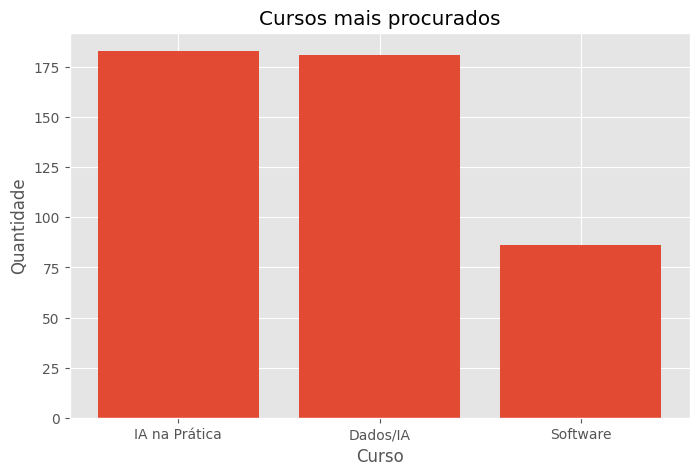

In [104]:
cursos = df['CursoInteresse'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    cursos.index,
    cursos.values
)

plt.title('Cursos mais procurados')
plt.xlabel('Curso')
plt.ylabel('Quantidade')

plt.show()


# 10. Gráfico de pizza para a preferência de contato


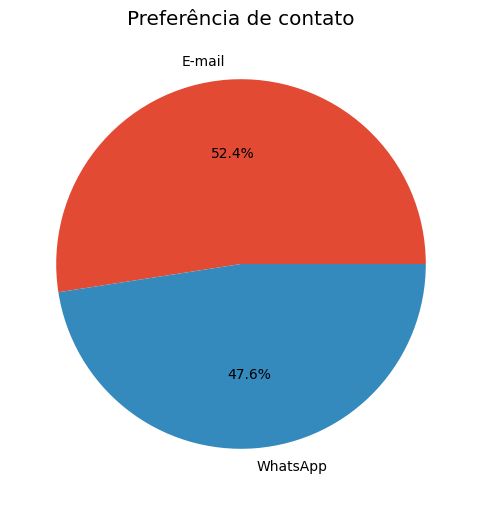

In [105]:
contatos = df['PreferenciaContato'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    contatos.values,
    labels=contatos.index,
    autopct='%1.1f%%'
)

plt.title('Preferência de contato')

plt.show()


# 11. Histograma para visualizar as idades


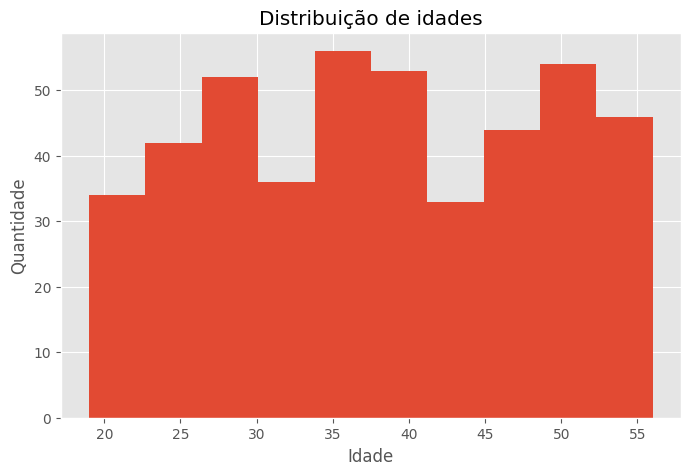

In [106]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Idade'],
    bins=10
)

plt.title('Distribuição de idades')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.show()


# 12. Descobrindo insights
Agora vamos responder algumas perguntas.


In [107]:
# Para saber o curso mais procurado
curso_mais_procurado = df['CursoInteresse'].mode()[0]

print(f'Curso mais procurado: {curso_mais_procurado}')

Curso mais procurado: IA na Prática


In [108]:
# Para saber o contato mais utilizado
contato_mais_usado = df['PreferenciaContato'].mode()[0]

print(f'Contato mais utilizado: {contato_mais_usado}')

Contato mais utilizado: E-mail


In [109]:
# Para saber a media de idade dos homens
media_homens = df[df['Genero'] == 'Masculino']['Idade'].mean()

print(f'Média de idade dos homens: {media_homens:.2f}')

Média de idade dos homens: 37.67



# 14. Treinando uma IA simples
Agora vamos utilizar os dados analisados para treinar uma Inteligência Artificial.

Nosso objetivo será prever qual curso uma pessoa possui maior interesse com base em características presentes no cadastro.

In [110]:
# Preparando os dados para treinar um modelo de IA

from sklearn.preprocessing import LabelEncoder
df_ml = df.copy()

encoder_genero = LabelEncoder()
encoder_cargo = LabelEncoder()
encoder_setor = LabelEncoder()
encoder_contato = LabelEncoder()
encoder_curso = LabelEncoder()

df_ml['Genero'] = encoder_genero.fit_transform(df_ml['Genero'])
df_ml['Cargo'] = encoder_cargo.fit_transform(df_ml['Cargo'])
df_ml['SetorAtuacao'] = encoder_setor.fit_transform(df_ml['SetorAtuacao'])
df_ml['PreferenciaContato'] = encoder_contato.fit_transform(df_ml['PreferenciaContato'])
df_ml['CursoInteresse'] = encoder_curso.fit_transform(df_ml['CursoInteresse'])

df_ml.head()

,Nome,DataNascimento,Genero,Cargo,SetorAtuacao,PreferenciaContato,CursoInteresse,Idade
0,Lionel Messi,1991-08-06,0,7,3,1,1,35
1,Lando Norris,1971-11-30,1,2,1,1,0,55
2,Charles Darwin,2000-11-24,1,6,0,1,0,26
3,Misty Waterflower,1981-06-12,1,1,4,1,1,45
4,Sundar Pichai,1997-11-26,1,1,7,1,0,29


In [111]:
# Definindo as variáveis para o modelo de IA

from sklearn.model_selection import train_test_split

X = df_ml[
  [
    'Idade',
    'Genero',
    'Cargo',
    'SetorAtuacao',
    'PreferenciaContato'
  ]
]

y = df_ml['CursoInteresse']

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 360
Teste: 90


In [112]:
# Treinando um modelo de IA
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
  max_depth=4,
  random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
# Avaliando o modelo treinado

from sklearn.metrics import accuracy_score

previsoes = modelo.predict(X_test)

acuracia = accuracy_score(
  y_test,
  previsoes
)

print(f'A IA acertou (acurácia) {acuracia:.2%} das previsões realizadas.')

Acurácia do modelo: 78.89%


In [ ]:
# Rodando o modelo e verificando a previsão

nova_pessoa = pd.DataFrame(
  {
    'Idade':[22],
    'Genero':[encoder_genero.transform(['Masculino'])[0]],
    'Cargo':[encoder_cargo.transform(['Engenheiro'])[0]],
    'SetorAtuacao':[encoder_setor.transform(['Saúde'])[0]],
    'PreferenciaContato':[encoder_contato.transform(['WhatsApp'])[0]]
  }
)

previsao = modelo.predict(nova_pessoa)

curso_previsto = encoder_curso.inverse_transform(previsao)

print(f'Previsão da IA: {curso_previsto[0]}')

Curso recomendado pela IA: Dados/IA


# 15. O que acabamos de fazer?

Fluxo utilizado: **Dados → Análise → Feature Engineering → Treinamento → Previsão**

Este é o mesmo princípio utilizado em diversas aplicações de Inteligência Artificial para apoiar decisões e gerar previsões.

# 16. Desafio final

Tente criar:
- um novo gráfico;
- uma nova análise;
- uma nova pergunta sobre os dados.

Exemplos:
- Qual setor possui mais pessoas?
- Qual faixa etária prefere IA?
- Qual curso é mais popular entre mulheres?